In [483]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error, root_mean_squared_error

# sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

 
# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

base_path = "/Users/kdt_0900_cjs/ml/resource/dataset"
file_name = "titanic.csv"
file_path = os.path.join(base_path, file_name)

df = pd.read_csv(file_path)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 타이타닉 데이터셋 입력 컬럼(Feature) 상세 설명

| 컬럼명 | 설명 및 의미 | 비고 / 값 예시 |  
| pclass | 객실 등급 (Ticket class) | 1 = 1등석, 2 = 2등석, 3 = 3등석 |  
| sex | 성별 | male (남성), female (여성) |  
| age | 나이 | 결측치 존재, 1세 미만은 소수점 표시 |  
| sibsp | 동승한 형제/자매/배우자의 수 | 0, 1, 2 ... |  
| parch | 동승한 부모/자녀의 수 | 0, 1, 2 ... |  
| fare | 탑승 요금 | 승객이 지불한 운임 (파운드화) |  
| embarked | 탑승 항구 코드 | C = Cherbourg, Q = Queenstown, S = Southampton |  
| class | 객실 등급 텍스트 | First, Second, Third (pclass와 동일 정보) |  
| who | 승객 구분 | man (성인 남성), woman (성인 여성), child (아이) |  
| deck | 선실 구역 번호 | A, B, C, D, E, F, G (결측치 매우 많음) |  
| embark_town | 탑승 도시 이름 | Cherbourg, Queenstown, Southampton |  
| alone | 혼자 탑승했는지 여부 | True (동승자 없음), False (동승자 있음) |  

In [484]:
# [문제 0] 프로젝트 목표 정의 (5점)

# 1. 데이터 수집·전처리부터 모델 학습, 성능 평가까지 이어지는 머신러닝 파이프라인의 전체 구조를 명확히 제시하세요.
# 데이터 수집 -> 전처리과정을 통해 이상치, 결측치를 파악해 영향을 미치는 이 값들을 제거할지 아니면 중앙값 혹은 최빈값등으로 채워넣을지 결정 -> 분류형 데이터 인코딩 -> 어떤 모델을 불러올지 데이터의 종류와 목적에 따라 모델 결정 
# 데이터를 훈련용, 테스트용으로 분류 -> 데이터에 따라 정규화 혹은 표준화 -> 모델 학습 -> 성능 평가
# 2. 학습(Train) 및 평가(Test) 과정에서 발생할 수 있는 데이터 누수(Data Leakage)를 방지하기 위한 데이터 분리 및 처리 전략을 포함하여 기술하세요.
# 데이터를 우선 학습/테스트 용으로 분리 -> 스케일링을 통해 표준화 혹은 정규화를 통해 알맞게 가공한다.
# 분리전에 스케일링 할 경우 에상치 못하게 값이 학습에 이용되지 못하거나 잘못 영향을 주는 데이터누수가 생길수잇으니 먼저 분리 후 스케일링 하도록 한다

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


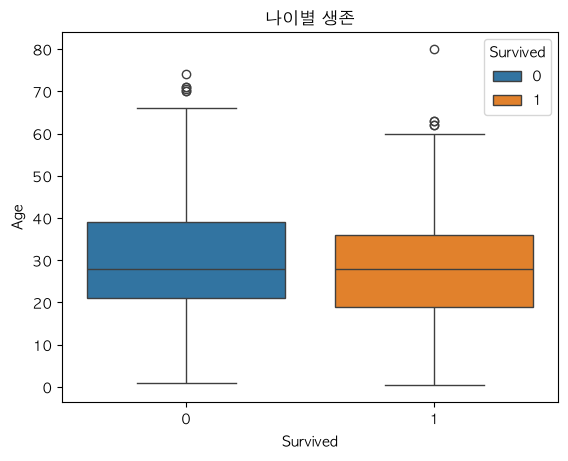

In [485]:
# 데이터의 행/열 개수, 컬럼명, 결측치 개수(컬럼별) 요약을 작성하고, 이상치를 탐색를 각 컬럼의 이상치로 판단하거나 이상치로 보지 않은 근거를 서술하세요(5점)
# Age : 177개
# Cabin : 687개
# 행 12개 열 891개
# 컬럼명 ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp','Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
# print(df.isna().sum())
print(df.describe())
sns.boxplot(df, x="Survived", y= "Age", hue="Survived")
plt.title("나이별 생존")
plt.show()
# 이상치로 볼수있는것 Age : 80, Fare : 512 하지만 모두 비싼 요금을 내고 좋은 방에 머문 사람의 생존이 높다거나, 나이별로 대피를 먼저 시켰거나 등의 요인이 있을수 잇기에 이상치를 제거하지 않는다.

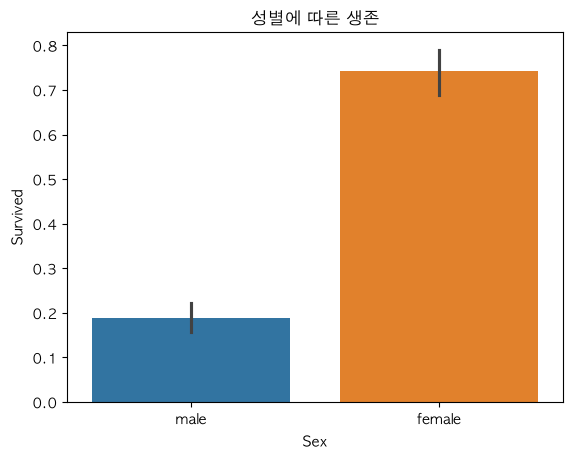

In [486]:
sns.barplot(df, x="Sex", y= "Survived", hue ="Sex")
plt.title("성별에 따른 생존")
plt.show()

In [487]:
#2. Survived 클래스 비율(생존/사망 비율)을 계산하고 해석하세요. (5점)
print(df["Survived"].value_counts(normalize = True) * 100)

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [488]:
# 1. 수치형/범주형 변수를 구분하라. (5점)
df.columns
# 수치형 : Age, SibSp, Parch, Fare
# 분류형 : PassengerId, Survived, Pclass,Name,Sex,Ticket, Cabin


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [489]:
# 2. 결측치 처리 전략을 각각 제시하세요. (예: age, embarked 등) (5점)
df.isna().sum()

# Age : 나이는 노약자 혹은 어린 아이부터 대피 시켰을 수 있으니 없애지 않고, 중앙값
# Cabin : 선실 등급은 Pclass로 대체가능하기대문에 생존율 확인에는 중요하지 않으니 삭제가능
# embarked : 중요하지 않으니 삭제

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [490]:
# 3. 범주형 인코딩 방법(원-핫 등)과 수치형 스케일링 필요 여부를 판단하고 근거를 서술하세요. (5점)
# 탑승 정보(성별, 연령, 객실 등급 등)를 기반으로 생존 여부판단이므로  범주형 원핫 인코딩 필요, 수치형 스케일링 필요여부 : max값 비교시 Fare가 512로 다른 값과 차이가 확연하므로 스케일링 필요
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [491]:
# 4. 스케일링을 표준화로 할지 정규화로 할지 판단 근거를 서술하세요. (5점)
# 표준화
# 이유 : 정규화를 하면 0과 1로 범위를 맞추는것 그러나 Fare의 최대값이 512로 이를 1로 치환할시 다른 값들이 너무 작아지는 문제가 발생하므로 표준화 필요

In [492]:
df
survived_df = df.drop(columns=["Cabin", "Embarked", "PassengerId"])
survived_df["Age"] = survived_df["Age"].fillna(survived_df["Age"].median())
survived_df.isna().sum()

survived_df = survived_df.drop(columns=["Name", "Ticket"])

In [493]:
# columns = survived_df.columns
# survived_df = pd.get_dummies(survived_df, columns=["Sex"], drop_first=True, dtype=int)
survived_df["Sex"] = survived_df["Sex"].map(lambda gender : {"male" : 0, "female" : 1}[gender])
survived_df["Pclass"] = survived_df["Sex"].map(lambda gender : {"male" : 0, "female" : 1}[gender])
survived_df.head()

KeyError: 0

In [ ]:
sns.barplot(survived_df, x="Pclass", y="Survived", hue="Pclass")
plt.title("객실 등급별 생존 비율")
plt.show()

In [ ]:
corr_matrix = survived_df.corr(numeric_only=True)
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True)
plt.title("상관관계 히트맵")
plt.show()

In [ ]:
X = survived_df.drop("Survived", axis = 1)
X.head()

In [ ]:
y = survived_df["Survived"]
y.head()

In [ ]:
# 2. 분리 시 stratify(계층화) 적용 여부를 결정하고 이유를 설명하세요. (8점)
# 이유 : 생존과 사망에 대한 데이터가 다양하게 섞여잇기 때문에 테스트나 훈련 데이터에 한쪽이 치우쳐져 나누어지면 학습에 영향이 갈수잇다고 생각
#3. 파라미터와 하이퍼파라미터의 차이를 서술하고, 하이퍼파라미터 튜닝을 “최소 1개 파라미터”만이라도 시도하세요.(5점)
# 하이퍼 파라미터 : 학습시 인간이 직접 설정하는 값
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026, stratify=y)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(X.columns)
vif

In [ ]:
# 모델 : Logistic Regression·
# 이유 : 생존 혹은 사망 즉 두개의 클래스를 가지는 범주형을 예측 따라서 이진분류 : Logistic Regression·

lr = LogisticRegression(max_iter=100)

In [ ]:
lr.fit(X_train_scaled, y_train)

In [ ]:
y_pred = lr.predict(X_test_scaled)

In [ ]:
train_score = lr.score(X_train_scaled, y_train)
test_score = lr.score(X_test_scaled, y_test)

print(f"훈련데이터 정확도 점수 : {train_score}")
print(f"테스트 데이터 정확도 점수 : {test_score}")

In [ ]:
print(f"모델의 예측 확율 : {lr.predict_proba(X_test_scaled)[:5]}")
print(f"모델의 예측 값 : {y_pred[:5]}")
print(f"모델의 정답 : {y_test.values[:5]}")

In [494]:
print(f"테스트 정확도 : {lr.score(X_train_scaled, y_train)}")
print(f"테스트 정확도 : {accuracy_score(y_pred=y_pred, y_true = y_test)}")

테스트 정확도 : 0.797752808988764
테스트 정확도 : 0.7821229050279329


In [498]:
lr = LogisticRegression(max_iter=500)
lr.fit(X_train_scaled, y_train)
y_pred1 = lr.predict(X_test_scaled)
print(f"테스트 정확도 : {accuracy_score(y_pred=y_pred1, y_true = y_test)}")

테스트 정확도 : 0.7821229050279329


In [ ]:
from sklearn.metrics import f1_score

y_pred = lr.predict(X_test_scaled)
print(f"f1 score : {f1_score(y_test, y_pred)}")


In [ ]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(lr, X_test_scaled, y_test)

In [ ]:
# 각 가중치 확인
coef_df = pd.DataFrame({
    "Features": X_train.columns,
    "Coef": lr.coef_[0]
}).sort_values(by = "Coef", ascending=False)

coef_df

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    lr,
    X_test_scaled,
    y_test,
    display_labels=["사망(0)", "생존(1)"],
    cmap="Blues"
)

plt.title("타이타닉 로지스틱 회귀 혼동행렬")
plt.show()
#혼동행렬 예측
"""
    실제사망, 예측 사망 : 90
    실제 사망, 예측 생존 : 20
    실제 생존, 예측 사망:  19
    실제 생존, 에측 생존 : 50

    실제 데이터와 예측이 둘다 맞은것은 각각 90, 50
    예측이 실제와 다르게 나온것은 20, 19
    
    따라서  실제값과 예측이 각각 110개중 90개를 맞추고
    69개중 50개를 맞추어 정확도를 약 78%정도이다
"""
None

#3. 어떤 오류가 더 치명적인지(예: 생존자를 사망으로 예측 vs 반대) 상황을 가정해 서술하세요. (5점)
# 가정1. 생존자를 사망으로 예측 : 비슷한 규모의 사고발생 확률을 예측시 위험성을 더 높게 측정
# 가정2. 사망자를 생존자로 예측 : 비슷한 규모의 사고발생 확률을 예측시 위험성을 더 낮게 측정, 사망자를 더 낮게 파악
# 결론 : 따라서  사망자를 생존자로 예측하는 것이 더 치명적이다

In [ ]:
print(classification_report(y_pred, y_test))